<a href="https://colab.research.google.com/github/vidhya2432/Gen-AI/blob/main/Mall_Customer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("/content/Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
X=df[['Annual Income (k$)','Spending Score (1-100)']]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


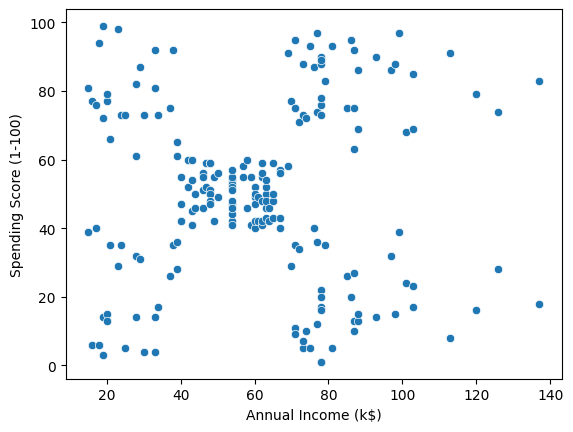

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x=X['Annual Income (k$)'],y=X['Spending Score (1-100)'])
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_X=scaler.fit_transform(X)
scaled_X

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=4)
df["Clusteter"]=kmeans.fit_predict(scaled_X)

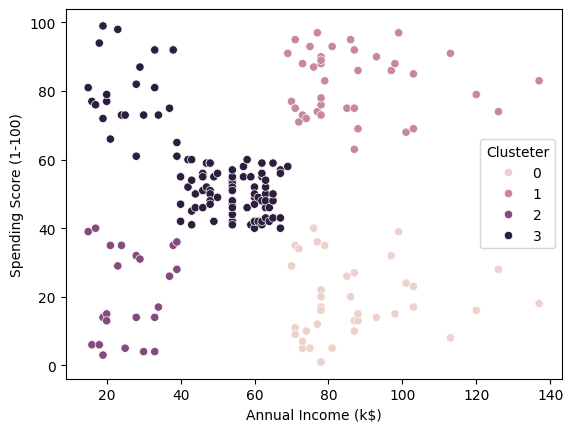

In [ ]:
sns.scatterplot(df,x='Annual Income (k$)',y='Spending Score (1-100)',hue="Clusteter")
plt.show()

In [ ]:
import gradio as gr
def predict_dis(income,annual):
  newcustemer=[[income,annual]]
  predict=kmeans.predict(scaler.transform(newcustemer))[0]
  return predict
demo=gr.Interface(
    fn=predict_dis,
    inputs=[
        gr.Number(),
        gr.Number()
     ],
     outputs="text"
)
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://09b4250085243efb32.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
###Recommedation System

In [ ]:
from mlxtend.frequent_patterns import TransationEncoder
from mlxtend.frequent_patterns import apriori,association_rules

ImportError: cannot import name 'TransationEncoder' from 'mlxtend.frequent_patterns' (/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/__init__.py)

In [ ]:
transcation=df.apply(lambda row:row.dropna().tolist(),axis=1).tolist()

In [ ]:
te=TransationEncoder()
te_ary=te.fit(transcation).transform(transcation)
decome=pd.DataFrame(te_ary,columns=te.columns_)
decome

In [ ]:
frequent=apriori(decome,min_support=0.01,use_colnames=True)
rules=association_rules(frequent,metric="confidence",min_threshold=1)
print(rules[["antecedents","consequents","support","confidence","lift"]])

In [ ]:
product=input("Enter Product Name:")

In [ ]:
if product:
  print("")
else:
  print("Top most product Recommeded on ur product like to buy")